In [1]:
%load_ext autoreload
%autoreload 2

from cdk.analysis.cytosol import platereader as pr
from cdk.logging import setup_logging, DEBUG

import pandas as pd
import seaborn as sns

log = setup_logging(log_level=DEBUG)

[04/03/25 13:18:54] INFO     Logging initialized                  __init__.py:41


In [72]:
data = pr.load_platereader_data("/data/bnext/experiments/20250228-ot-pierce660/data/20250402-ot-pierce660-mc-biotek-cdk-withsample.txt")
data

[04/03/25 14:07:18] DEBUG    Reading CDK-formatted BioTeik    platereader.py:204
                             data from                                          
                             /data/bnext/experiments/20250228                   
                             -ot-pierce660/data/20250402-ot-p                   
                             ierce660-mc-biotek-cdk-withsampl                   
                             e.txt                                              
                    DEBUG    Loaded section Pierce660         platereader.py:215


,index,Well ID,Conc/Dil type,Conc/Dil,Unit,Read,Data,Type,Sample,Name
0,0,SPL1,Dil.,1,NaN,660-A:660,0.037,SPL,1,SPL1
1,1,SPL1,Dil.,2,NaN,660-A:660,0.038,SPL,1,SPL1
2,2,SPL1,Dil.,4,NaN,660-A:660,0.037,SPL,1,SPL1
3,3,SPL1,Dil.,8,NaN,660-A:660,0.037,SPL,1,SPL1
4,4,SPL2,Dil.,1,NaN,660-A:660,0.038,SPL,2,SPL2
...,...,...,...,...,...,...,...,...,...,...
175,175,STD7,Conc.,125,mg/mL,660-C3:660,0.307,STD,7,STD7
176,176,STD7,Conc.,125,mg/mL,660-C3:660,0.265,STD,7,STD7
177,177,STD8,Conc.,0,mg/mL,660-C3:660,0.077,STD,8,STD8
178,178,STD8,Conc.,0,mg/mL,660-C3:660,0.081,STD,8,STD8


In [73]:
curves = pr.compute_standard_curve(data)
curves

,Type,Read,slope,intercept,R
0,STD,660-A:660,0.000652,0.419733,0.874144
1,STD,660-B:660,0.000648,0.329314,0.937923
2,STD,660-C1:660,0.000692,0.311413,0.946591
3,STD,660-C2:660,0.000690,0.308854,0.946932
4,STD,660-C3:660,0.000691,0.307761,0.947167


In [48]:
import numpy as np

# Sample dataframe
df = pd.DataFrame({
    'start': [0, 10, 20],
    'end': [5, 15, 25],
    'step': [1, 0.5, 2]
})

def expand_to_points(row):
    return pd.DataFrame({
        'point': np.arange(row['start'], row['end'] + row['step'], row['step'])
    })

# Apply the function to each row and concatenate the results
result = df.apply(expand_to_points, axis=1).reset_index(drop=True)

result.index

RangeIndex(start=0, stop=3, step=1)

<Axes: xlabel='Concentration (nan)', ylabel='Relative Fluorescence Units (RFU)'>

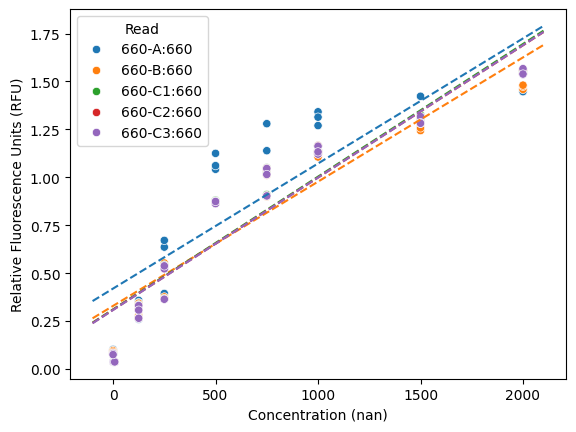

In [39]:
lines = pr.plot_standard_curve(data)
lines

In [51]:
conc = pd.merge(data, curves, on=["Type", "Read"], suffixes=("", "_y"))
conc["Concentration"] = (conc["Data"] - conc["intercept"]) / conc["slope"]
conc

,index,Well ID,Conc/Dil type,Conc/Dil,Unit,Read,Data,Type,Sample,Name,slope,intercept,R,Concentration
0,12,STD1,Conc.,2000,mg/mL,660-A:660,1.461,STD,1,STD1,0.000652,0.419733,0.874144,1595.848184
1,13,STD1,Conc.,2000,mg/mL,660-A:660,1.447,STD,1,STD1,0.000652,0.419733,0.874144,1574.391759
2,14,STD1,Conc.,2000,mg/mL,660-A:660,1.548,STD,1,STD1,0.000652,0.419733,0.874144,1729.184544
3,15,STD2,Conc.,1500,mg/mL,660-A:660,1.308,STD,2,STD2,0.000652,0.419733,0.874144,1361.360104
4,16,STD2,Conc.,1500,mg/mL,660-A:660,1.309,STD,2,STD2,0.000652,0.419733,0.874144,1362.892706
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
115,175,STD7,Conc.,125,mg/mL,660-C3:660,0.307,STD,7,STD7,0.000691,0.307761,0.947167,-1.101033
116,176,STD7,Conc.,125,mg/mL,660-C3:660,0.265,STD,7,STD7,0.000691,0.307761,0.947167,-61.898692
117,177,STD8,Conc.,0,mg/mL,660-C3:660,0.077,STD,8,STD8,0.000691,0.307761,0.947167,-334.040594
118,178,STD8,Conc.,0,mg/mL,660-C3:660,0.081,STD,8,STD8,0.000691,0.307761,0.947167,-328.250341


In [74]:
data

,index,Well ID,Conc/Dil type,Conc/Dil,Unit,Read,Data,Type,Sample,Name
0,0,SPL1,Dil.,1,NaN,660-A:660,0.037,SPL,1,SPL1
1,1,SPL1,Dil.,2,NaN,660-A:660,0.038,SPL,1,SPL1
2,2,SPL1,Dil.,4,NaN,660-A:660,0.037,SPL,1,SPL1
3,3,SPL1,Dil.,8,NaN,660-A:660,0.037,SPL,1,SPL1
4,4,SPL2,Dil.,1,NaN,660-A:660,0.038,SPL,2,SPL2
...,...,...,...,...,...,...,...,...,...,...
175,175,STD7,Conc.,125,mg/mL,660-C3:660,0.307,STD,7,STD7
176,176,STD7,Conc.,125,mg/mL,660-C3:660,0.265,STD,7,STD7
177,177,STD8,Conc.,0,mg/mL,660-C3:660,0.077,STD,8,STD8
178,178,STD8,Conc.,0,mg/mL,660-C3:660,0.081,STD,8,STD8


<Axes: xlabel='Name', ylabel='Concentration'>

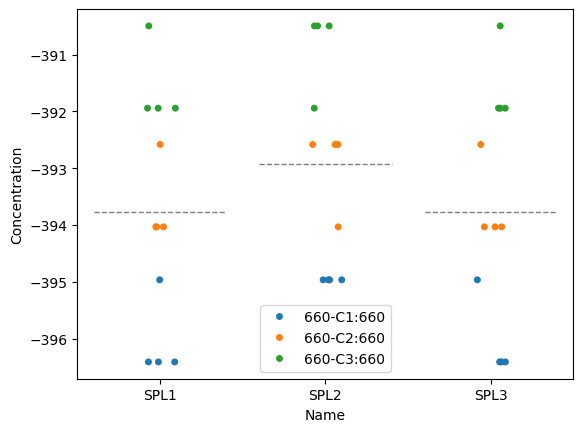

In [79]:
pr.plot_concentration(data[data["Read"].str.contains("660-C")])

In [ ]:
merged_mean = merged[merged["Read"].str.contains("660-")].groupby(["Well ID", "Well", "Conc/Dil", "Type", "Experiment"])["Data"].mean().reset_index()
samples_mean = pd.merge(merged_mean[(merged_mean["Type"].str.contains("SPL"))], slopes_mean, how="left", on=["Experiment"], suffixes=("", "_y"))
samples_mean["Concentration"] = (samples_mean["Data"] - samples_mean["intercept"]) / samples_mean["slope"]
samples_mean["Concentration x Dilution"] = samples_mean["Concentration"] * samples_mean["Conc/Dil"] /1000
samples_mean